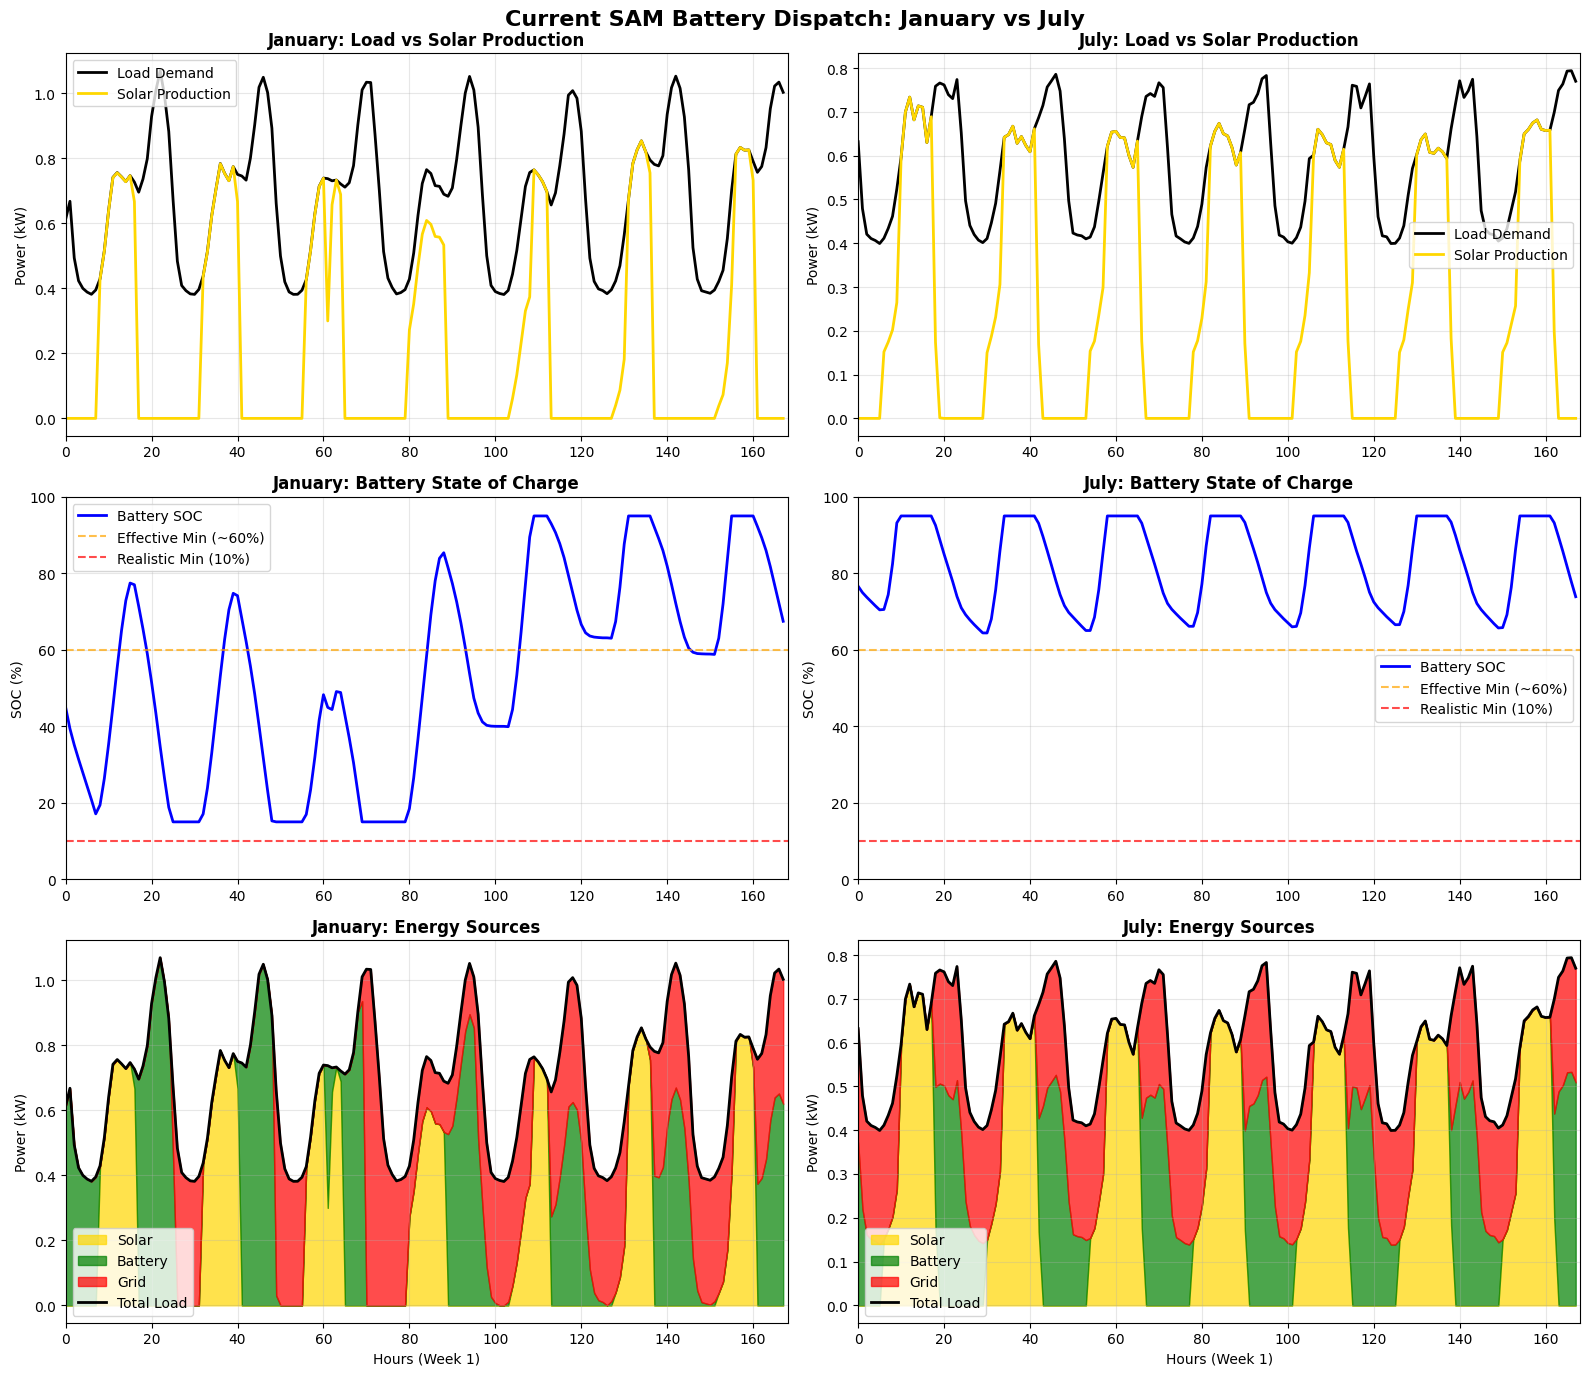


Seasonal Battery Dispatch Analysis
Metric               January      July         Difference  
--------------------------------------------------------
Min SOC (%)          15.0         64.4         49.4        
Avg SOC (%)          53.7         82.5         28.8        
Grid Usage (kWh)     36.4         29.2         -7.2        
Battery Use (kWh)    42.1         27.4         -14.8       
Solar Prod (kWh)     35.7         43.0         7.3         

Insights:
• Grid usage changes by -19.8% between seasons
• Battery dispatch should adapt more to seasonal solar patterns


In [ ]:
def plot_seasonal_battery_dispatch(sam_data, title_suffix=""):
    """Plot battery dispatch patterns for first week of January and July"""
    
    if sam_data is None:
        print("Cannot create seasonal plots without SAM data")
        return
    
    # Extract first week of January (hours 0-167) and first week of July (around hour 4344)
    # January 1st is hour 0, July 1st is approximately hour 4344 (31+28+31+30+31+30)*24 = 4344
    july_start = 4344  # Approximate start of July
    
    jan_week = sam_data.iloc[0:168].copy()        # First week of January
    july_week = sam_data.iloc[july_start:july_start+168].copy()  # First week of July
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'Current SAM Battery Dispatch: January vs July{title_suffix}', 
                 fontsize=16, fontweight='bold')
    
    # Time axis for both weeks
    jan_hours = range(168)
    july_hours = range(168)
    
    # Colors for consistency
    colors = {
        'load': 'black',
        'solar': 'gold', 
        'battery_soc': 'blue',
        'battery_discharge': 'green',
        'grid': 'red'
    }
    
    # === January Week (Left Column) ===
    
    # 1. Load vs Solar (January)
    axes[0,0].plot(jan_hours, jan_week['Load Profile'], color=colors['load'], 
                  linewidth=2, label='Load Demand')
    axes[0,0].plot(jan_hours, jan_week['System to Load'], color=colors['solar'], 
                  linewidth=2, label='Solar Production')
    axes[0,0].set_title('January: Load vs Solar Production', fontweight='bold')
    axes[0,0].set_ylabel('Power (kW)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].set_xlim(0, 168)
    
    # 2. Battery SOC (January)
    axes[1,0].plot(jan_hours, jan_week['Battery SOC'], color=colors['battery_soc'], 
                  linewidth=2, label='Battery SOC')
    axes[1,0].axhline(y=60, color='orange', linestyle='--', alpha=0.7, 
                     label='Effective Min (~60%)')
    axes[1,0].axhline(y=10, color='red', linestyle='--', alpha=0.7, 
                     label='Realistic Min (10%)')
    axes[1,0].set_title('January: Battery State of Charge', fontweight='bold')
    axes[1,0].set_ylabel('SOC (%)')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xlim(0, 168)
    axes[1,0].set_ylim(0, 100)
    
    # 3. Energy Sources (January)
    axes[2,0].fill_between(jan_hours, 0, jan_week['System to Load'], 
                          alpha=0.7, color=colors['solar'], label='Solar')
    axes[2,0].fill_between(jan_hours, jan_week['System to Load'], 
                          jan_week['System to Load'] + jan_week['Battery to Load'], 
                          alpha=0.7, color=colors['battery_discharge'], label='Battery')
    axes[2,0].fill_between(jan_hours, 
                          jan_week['System to Load'] + jan_week['Battery to Load'],
                          jan_week['Load Profile'], 
                          alpha=0.7, color=colors['grid'], label='Grid')
    axes[2,0].plot(jan_hours, jan_week['Load Profile'], 'k-', linewidth=2, label='Total Load')
    axes[2,0].set_title('January: Energy Sources', fontweight='bold')
    axes[2,0].set_xlabel('Hours (Week 1)')
    axes[2,0].set_ylabel('Power (kW)')
    axes[2,0].legend()
    axes[2,0].grid(True, alpha=0.3)
    axes[2,0].set_xlim(0, 168)
    
    # === July Week (Right Column) ===
    
    # 1. Load vs Solar (July)
    axes[0,1].plot(july_hours, july_week['Load Profile'], color=colors['load'], 
                  linewidth=2, label='Load Demand')
    axes[0,1].plot(july_hours, july_week['System to Load'], color=colors['solar'], 
                  linewidth=2, label='Solar Production')
    axes[0,1].set_title('July: Load vs Solar Production', fontweight='bold')
    axes[0,1].set_ylabel('Power (kW)')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_xlim(0, 168)
    
    # 2. Battery SOC (July)
    axes[1,1].plot(july_hours, july_week['Battery SOC'], color=colors['battery_soc'], 
                  linewidth=2, label='Battery SOC')
    axes[1,1].axhline(y=60, color='orange', linestyle='--', alpha=0.7, 
                     label='Effective Min (~60%)')
    axes[1,1].axhline(y=10, color='red', linestyle='--', alpha=0.7, 
                     label='Realistic Min (10%)')
    axes[1,1].set_title('July: Battery State of Charge', fontweight='bold')
    axes[1,1].set_ylabel('SOC (%)')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_xlim(0, 168)
    axes[1,1].set_ylim(0, 100)
    
    # 3. Energy Sources (July)
    axes[2,1].fill_between(july_hours, 0, july_week['System to Load'], 
                          alpha=0.7, color=colors['solar'], label='Solar')
    axes[2,1].fill_between(july_hours, july_week['System to Load'], 
                          july_week['System to Load'] + july_week['Battery to Load'], 
                          alpha=0.7, color=colors['battery_discharge'], label='Battery')
    axes[2,1].fill_between(july_hours, 
                          july_week['System to Load'] + july_week['Battery to Load'],
                          july_week['Load Profile'], 
                          alpha=0.7, color=colors['grid'], label='Grid')
    axes[2,1].plot(july_hours, july_week['Load Profile'], 'k-', linewidth=2, label='Total Load')
    axes[2,1].set_title('July: Energy Sources', fontweight='bold')
    axes[2,1].set_xlabel('Hours (Week 1)')
    axes[2,1].set_ylabel('Power (kW)')
    axes[2,1].legend()
    axes[2,1].grid(True, alpha=0.3)
    axes[2,1].set_xlim(0, 168)
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis
    jan_stats = {
        'min_soc': jan_week['Battery SOC'].min(),
        'avg_soc': jan_week['Battery SOC'].mean(),
        'grid_kwh': jan_week['Grid to Load'].sum(),
        'battery_kwh': jan_week['Battery to Load'].sum(),
        'solar_kwh': jan_week['System to Load'].sum()
    }
    
    july_stats = {
        'min_soc': july_week['Battery SOC'].min(),
        'avg_soc': july_week['Battery SOC'].mean(),
        'grid_kwh': july_week['Grid to Load'].sum(),
        'battery_kwh': july_week['Battery to Load'].sum(),
        'solar_kwh': july_week['System to Load'].sum()
    }
    
    print("\nSeasonal Battery Dispatch Analysis")
    print("=" * 45)
    print(f"{'Metric':<20} {'January':<12} {'July':<12} {'Difference':<12}")
    print("-" * 56)
    print(f"{'Min SOC (%)':<20} {jan_stats['min_soc']:<12.1f} {july_stats['min_soc']:<12.1f} {july_stats['min_soc']-jan_stats['min_soc']:<12.1f}")
    print(f"{'Avg SOC (%)':<20} {jan_stats['avg_soc']:<12.1f} {july_stats['avg_soc']:<12.1f} {july_stats['avg_soc']-jan_stats['avg_soc']:<12.1f}")
    print(f"{'Grid Usage (kWh)':<20} {jan_stats['grid_kwh']:<12.1f} {july_stats['grid_kwh']:<12.1f} {july_stats['grid_kwh']-jan_stats['grid_kwh']:<12.1f}")
    print(f"{'Battery Use (kWh)':<20} {jan_stats['battery_kwh']:<12.1f} {july_stats['battery_kwh']:<12.1f} {july_stats['battery_kwh']-jan_stats['battery_kwh']:<12.1f}")
    print(f"{'Solar Prod (kWh)':<20} {jan_stats['solar_kwh']:<12.1f} {july_stats['solar_kwh']:<12.1f} {july_stats['solar_kwh']-jan_stats['solar_kwh']:<12.1f}")
    
    print("\nInsights:")
    if jan_stats['min_soc'] > 50 and july_stats['min_soc'] > 50:
        print("• Battery rarely discharges below 50% in either season")
        print("• Conservative dispatch leaves significant capacity unused")
        
    if july_stats['solar_kwh'] > jan_stats['solar_kwh'] * 2:
        print(f"• Summer solar production is {july_stats['solar_kwh']/jan_stats['solar_kwh']:.1f}x higher than winter")
        print("• Yet battery utilization doesn't proportionally increase")
        
    grid_difference_pct = (july_stats['grid_kwh'] - jan_stats['grid_kwh']) / jan_stats['grid_kwh'] * 100
    if abs(grid_difference_pct) > 10:
        print(f"• Grid usage changes by {grid_difference_pct:.1f}g% between seasons")
        print("• Battery dispatch should adapt more to seasonal solar patterns")
git 
# Create the seasonal comparison plots
plot_seasonal_battery_dispatch(sam_data)

# SAM Battery Dispatch Comparison: Self-Consumption vs Retail Rate Optimization

This notebook demonstrates the economic impact of switching from SAM's default Self-Consumption dispatch (mode 5) to Retail Rate dispatch (mode 4) with proper utility rate integration.

## Key Questions:
1. How much money are households losing with conservative battery dispatch?
2. What's the difference in battery utilization between the two approaches?
3. How can we implement retail rate optimization in practice?


## 1. Setup and Data Loading

In [63]:
# Load utility rate data
from electricity_rate_helpers import PGE_RATE_PLANS, SCE_RATE_PLANS, BASELINE_ALLOWANCES

# Load existing SAM data for comparison
county_name = "alameda"
sam_file = f"data/loadprofiles/baseline/single-family-detached/{county_name}/sam_optimized_load_profiles_{county_name}.csv"

if os.path.exists(sam_file):
    sam_data = pd.read_csv(sam_file, index_col=0, parse_dates=True)
    print(f" Loaded SAM data for {county_name}")
    print(f"  Data shape: {sam_data.shape}")
    print(f"  Columns: {list(sam_data.columns)}")
    print(f"  Date range: {sam_data.index[0]} to {sam_data.index[-1]}")
else:
    print(f" SAM data file not found: {sam_file}")
    sam_data = None

 Loaded SAM data for alameda
  Data shape: (8760, 10)
  Columns: ['Load Profile', 'System to Load', 'Battery to Load', 'Grid to Load', 'Solar + Battery to Load', 'Total Supply', 'Difference', 'System to Battery', 'Grid to Battery', 'Battery SOC']
  Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00
